In [48]:
import pandas as pd
from dictionaries import amino_acids
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("/Users/bani4ki/Documents/programming_project_bioinformatics/datasets/dataset_A.csv")

In [3]:
df.head()

,Sequence,Functional_class
0,MNTSAPPAVSPNITVLAPGKGPWQVAFIGITTGLLSLATVTGNLLV...,G protein-coupled receptor
1,MQKARGTRGEDAGTRAPPSPGVPPKRAKVGAGRGVLVTGAGAGAPV...,Kinase
2,MQAGSWVVGGGDSDSRVLSIQSHVVRGYVGNRAATFPLQVLGFEVD...,Kinase
3,MASLRGSETMCNITTSCNVDSNIDQFFQPTLYIIVIVLGFPTNCMA...,G protein-coupled receptor
4,MEYMSTGSDEKEEIDLLINHLNVSEVLDIMENLYASEEPAVYEPSL...,Kinase


- sequence length,
- number of occurrences of each amino acid,
- frequency of each amino acid,
- proportion of hydrophobic amino acids,
- proportion of charged amino acids, or
- other sequence-derived features.

In [4]:
df["Sequence_length"] = df["Sequence"].str.len()

In [5]:
def amino_acid_composition(sequence):
    metrics = {}
    sequence = sequence.upper()
    
    for aa in amino_acids.keys():
        count = sequence.count(aa)
        metrics[f"{aa}_count"] = count
        frequency = count/len(sequence)
        metrics[f"{aa}_fq"] = round(frequency, 2)    

    return metrics

Test function:

In [6]:
print(amino_acid_composition("NTSAPPAVSPNITVLAPGKGPW"))

{'A_count': 3, 'A_fq': 0.14, 'R_count': 0, 'R_fq': 0.0, 'N_count': 2, 'N_fq': 0.09, 'D_count': 0, 'D_fq': 0.0, 'C_count': 0, 'C_fq': 0.0, 'E_count': 0, 'E_fq': 0.0, 'Q_count': 0, 'Q_fq': 0.0, 'G_count': 2, 'G_fq': 0.09, 'H_count': 0, 'H_fq': 0.0, 'I_count': 1, 'I_fq': 0.05, 'L_count': 1, 'L_fq': 0.05, 'K_count': 1, 'K_fq': 0.05, 'M_count': 0, 'M_fq': 0.0, 'F_count': 0, 'F_fq': 0.0, 'P_count': 5, 'P_fq': 0.23, 'S_count': 2, 'S_fq': 0.09, 'T_count': 2, 'T_fq': 0.09, 'W_count': 1, 'W_fq': 0.05, 'Y_count': 0, 'Y_fq': 0.0, 'V_count': 2, 'V_fq': 0.09}


In [7]:
amino_acid_comp_df = df["Sequence"].apply(amino_acid_composition).apply(pd.Series)

In [8]:
df = pd.concat([df, amino_acid_comp_df], axis = 1)

In [47]:
def calculate_properties(sequence):
    metrics = {}
    sequence = sequence.upper()

    hydrophobic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("hydrophobic") == True
    )
    metrics[f"Hydrophobic_fq"] = round(hydrophobic/len(sequence),2)
    
    aromatic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("aromatic") == True
    )
    metrics[f"Aromatic_fq"] = round(aromatic/len(sequence),2)
    
    charged = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("charge") != "neutral"
    )
    metrics[f"Charged_fq"] = round(charge/len(sequence),2)
    
    return metrics

Test function:

In [10]:
calculate_properties("NTSAPPAVSPNITVLAPGKGPW")

{'Hydrophobic_fq': 0.68, 'Aromatic_fq': 0.05, 'Charged_fq': 0.05}

In [11]:
calculate_properties(df.at[0,"Sequence"])

{'Hydrophobic_fq': 0.55, 'Aromatic_fq': 0.1, 'Charged_fq': 0.1}

In [12]:
amino_acid_props_df = df["Sequence"].apply(calculate_properties).apply(pd.Series)
df = pd.concat([df, amino_acid_props_df], axis = 1)

^need to think of a way to not add it ten times?

In [13]:
df.head()

,Sequence,Functional_class,Sequence_length,A_count,A_fq,R_count,R_fq,N_count,N_fq,D_count,...,T_fq,W_count,W_fq,Y_count,Y_fq,V_count,V_fq,Hydrophobic_fq,Aromatic_fq,Charged_fq
0,MNTSAPPAVSPNITVLAPGKGPWQVAFIGITTGLLSLATVTGNLLV...,G protein-coupled receptor,460,37.0,0.08,32.0,0.07,15.0,0.03,11.0,...,0.08,13.0,0.03,16.0,0.03,26.0,0.06,0.55,0.10,0.10
1,MQKARGTRGEDAGTRAPPSPGVPPKRAKVGAGRGVLVTGAGAGAPV...,Kinase,3259,278.0,0.09,299.0,0.09,43.0,0.01,129.0,...,0.05,35.0,0.01,57.0,0.02,217.0,0.07,0.51,0.07,0.07
2,MQAGSWVVGGGDSDSRVLSIQSHVVRGYVGNRAATFPLQVLGFEVD...,Kinase,322,25.0,0.08,18.0,0.06,11.0,0.03,21.0,...,0.05,4.0,0.01,10.0,0.03,39.0,0.12,0.52,0.10,0.10
3,MASLRGSETMCNITTSCNVDSNIDQFFQPTLYIIVIVLGFPTNCMA...,G protein-coupled receptor,373,30.0,0.08,15.0,0.04,18.0,0.05,14.0,...,0.06,7.0,0.02,16.0,0.04,29.0,0.08,0.59,0.14,0.14
4,MEYMSTGSDEKEEIDLLINHLNVSEVLDIMENLYASEEPAVYEPSL...,Kinase,467,26.0,0.06,26.0,0.06,16.0,0.03,25.0,...,0.04,5.0,0.01,19.0,0.04,28.0,0.06,0.49,0.11,0.11


In [14]:
df_rf = df.loc[ : , (df.columns != "Sequence")]

In [16]:
X,y = df_rf.loc[ : , (df_rf.columns != "Functional_class")], df_rf["Functional_class"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size = 0.25, random_state = 42)

In [18]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val) 
X_test = scaler.transform(X_test)

In [22]:
rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_train,y_train)

y_pred = rf_model.predict(X_val)

print(accuracy_score(y_val, y_pred))
print(classification_report(y_val,y_pred))
print(confusion_matrix(y_val,y_pred))

0.8650602409638555
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       111
           1       0.81      0.79      0.80       375
           2       0.92      0.64      0.76        53
           3       0.87      0.91      0.89       706

    accuracy                           0.87      1245
   macro avg       0.90      0.82      0.85      1245
weighted avg       0.87      0.87      0.86      1245

[[106   4   0   1]
 [  2 296   0  77]
 [  0   3  34  16]
 [  0  62   3 641]]


In [33]:
mapping_df = df_rf[['Functional_class']].copy() 
mapping_df['Functional_class_encoded'] = label_encoder.transform(df_rf['Functional_class'].values)
mapping_df = mapping_df.drop_duplicates('Functional_class')
mapping_df = mapping_df.sort_values('Functional_class_encoded',ignore_index = True)
print(mapping_df)

             Functional_class  Functional_class_encoded
0  G protein-coupled receptor                         0
1                      Kinase                         1
2           Ribosomal protein                         2
3               Transcription                         3


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3,5, 10, 20],
    'max_features':["sqrt","log2", None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring = 'accuracy', n_jobs = -1, verbose = 2)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

^^Best Score: 0.8663008415649953
Best Estimator: RandomForestClassifier(bootstrap=False, max_depth=20, random_state=42)

In [44]:
y_pred = best_rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.8698795180722891
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        94
           1       0.82      0.78      0.80       390
           2       0.96      0.76      0.85        33
           3       0.88      0.92      0.90       728

    accuracy                           0.87      1245
   macro avg       0.91      0.84      0.87      1245
weighted avg       0.87      0.87      0.87      1245

[[ 84   8   0   2]
 [  3 305   0  82]
 [  0   3  25   5]
 [  0  58   1 669]]


Text(0.5, 1.0, 'Feature Importances')

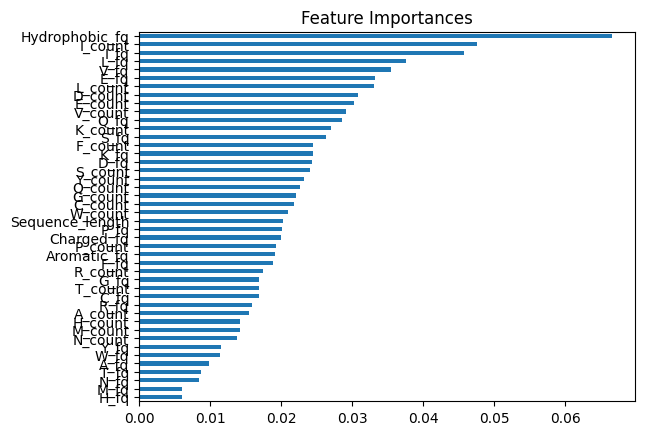

In [46]:
feature_importance = best_rf.feature_importances_
feature_names = X.columns
importances = pd.Series(best_rf.feature_importances_, index = X.columns).sort_values(ascending=True)
ax = importances.plot.barh()
ax.set_title('Feature Importances')

In [53]:
print(best_rf)
print(len(best_rf.feature_importances_))
print(len(X.columns))

RandomForestClassifier(bootstrap=False, max_depth=20, random_state=42)
44
44


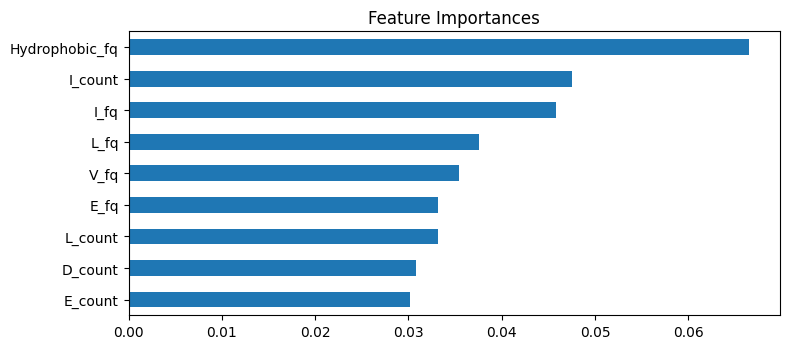

In [55]:
importances_filtered = importances[importances > 0.03]
fig, ax = plt.subplots(figsize=(8, len(importances_filtered) * 0.4))
importances_filtered.plot.barh(ax=ax)
ax.set_title('Feature Importances')
plt.tight_layout()
plt.show()